# Exploratory Data Analysis (EDA)

In [33]:
import warnings
warnings.filterwarnings("ignore")

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [36]:
df = pd.read_csv("../dataset/cleaned_data.csv")
df.head()

,Call_Timestamp,Patient_Age,Patient_Gender,State,Language,New_or_Existing_Patient,Call_Channel,Caller_Relationship,Chief_Complaint,Symptoms_Reported,Symptom_Severity,Duration_of_Symptoms_Days,Pain_Score,Emergency_Flag,Chronic_Condition,Insurance_Type,Preferred_Appointment_Urgency,Prior_Hospital_Visit_30D,Call_Duration_Minutes,Wait_Time_Minutes,Repeat_Caller,Sentiment,Call_Transcript_Summary,Recommended_Department
0,2025-02-27 20:09:18,33,Female,Alaska,English,Existing,Phone,Self,Needs to see a doctor and agent every,mild fever; blood pressure follow-up; general ...,High,10,9,No,Hypertension,Medicaid,Immediate,Yes,17,1,No,Anxious,Caller reached the hospital call center genera...,Primary Care
1,2025-06-27 20:33:38,27,Male,Louisiana,English,Existing,Phone,Self,"Caller reports abdominal pain, vomiting",abdominal pain; vomiting; acid reflux,Low,21,6,No,No Chronic Condition,Private,Routine,No,9,5,No,Calm,Family member called the access center stomach...,Gastroenterology
2,2026-01-09 06:34:10,38,Male,Arizona,English,New,Phone,Caregiver,"Caller reports needs specialist slot, book app...",needs specialist slot; book appointment,Medium,14,3,No,No Chronic Condition,Private,Routine,No,11,3,No,Anxious,Caller reached the hospital call center appoin...,Scheduling
3,2025-09-01 10:33:37,7,Female,Connecticut,English,Existing,Phone,Parent,"Patient is dealing with skin lesion, acne flare",skin lesion; acne flare,Low,93,1,No,Multiple,Medicaid,Soon,No,25,9,No,Distressed,Family member called the access center dermato...,Dermatology
4,2024-10-07 16:00:57,17,Male,Iowa,English,Existing,Phone,Self,"Parent says child has fatigue, weight loss",fatigue; weight loss,Medium,83,3,No,Multiple,Private,Soon,Yes,12,9,No,Distressed,Family member called the access center oncolog...,Pediatrics


In [37]:
df.shape

(10000, 24)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Call_Timestamp                 10000 non-null  object
 1   Patient_Age                    10000 non-null  int64 
 2   Patient_Gender                 10000 non-null  object
 3   State                          10000 non-null  object
 4   Language                       10000 non-null  object
 5   New_or_Existing_Patient        10000 non-null  object
 6   Call_Channel                   10000 non-null  object
 7   Caller_Relationship            10000 non-null  object
 8   Chief_Complaint                10000 non-null  object
 9   Symptoms_Reported              10000 non-null  object
 10  Symptom_Severity               10000 non-null  object
 11  Duration_of_Symptoms_Days      10000 non-null  int64 
 12  Pain_Score                     10000 non-null  int64 
 13  Em

# Univariate Analysis

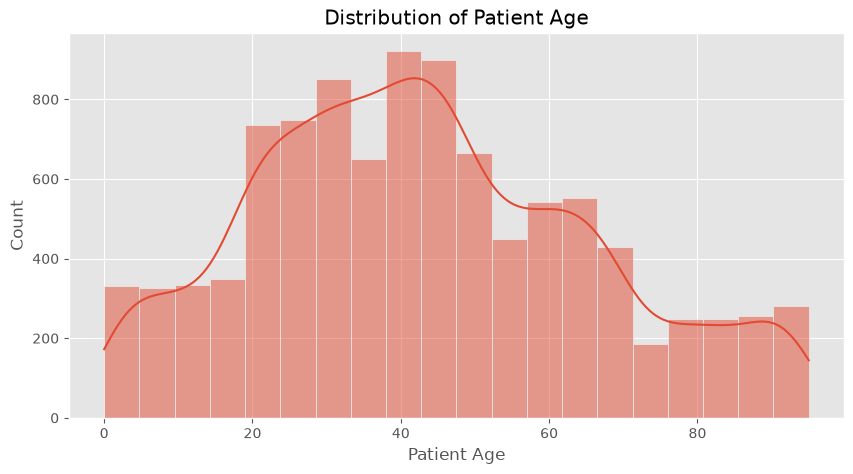

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x="Patient_Age", bins=20, kde=True)

plt.title("Distribution of Patient Age")
plt.xlabel("Patient Age")
plt.ylabel("Count")

plt.show()

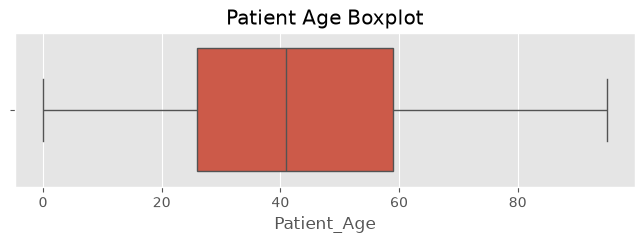

In [40]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["Patient_Age"])
plt.title("Patient Age Boxplot")

plt.show()

In [41]:
# Statistical Summary of Patient Age
df["Patient_Age"].describe()

count    10000.000000
mean        43.093500
std         22.646873
min          0.000000
25%         26.000000
50%         41.000000
75%         59.000000
max         95.000000
Name: Patient_Age, dtype: float64

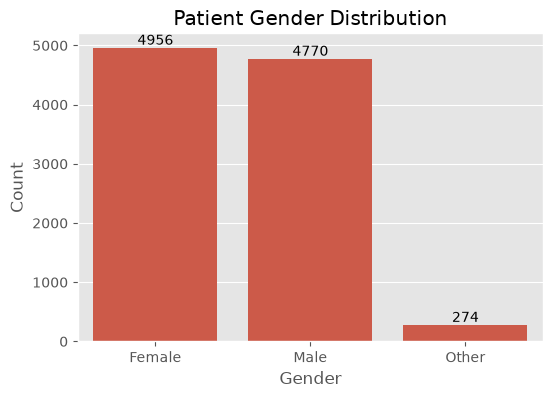

In [42]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="Patient_Gender")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Patient Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

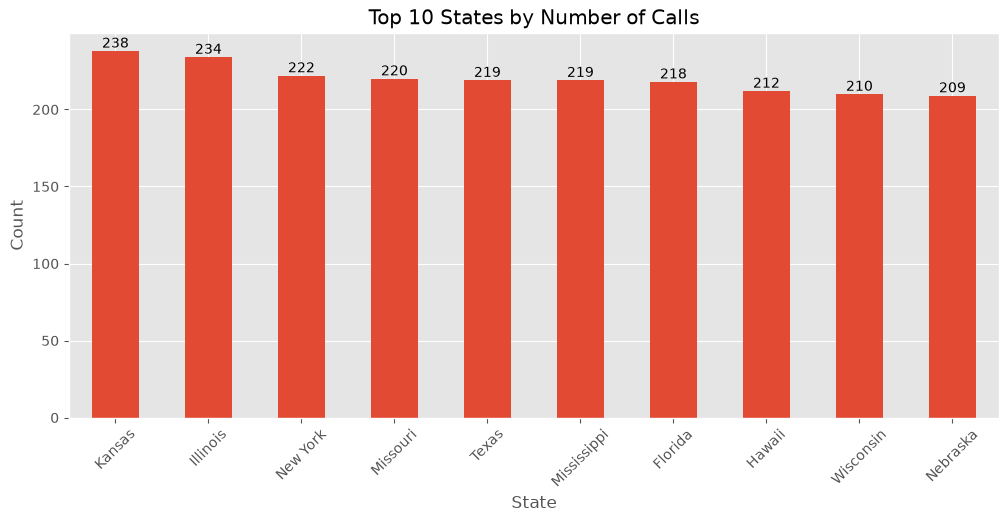

In [43]:
plt.figure(figsize=(12,5))
ax = df["State"].value_counts().head(10).plot(kind="bar")

# Add count labels on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 States by Number of Calls")
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

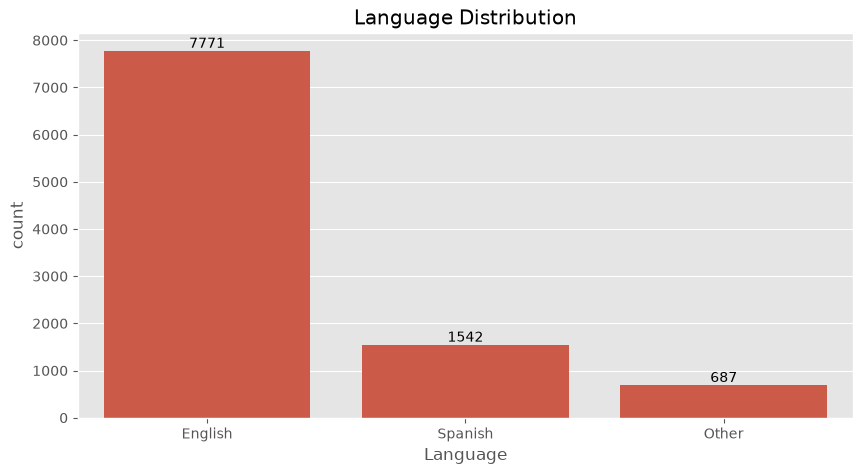

In [44]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x="Language", order=df["Language"].value_counts().index)

# Add count labels on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Language Distribution")
plt.show()

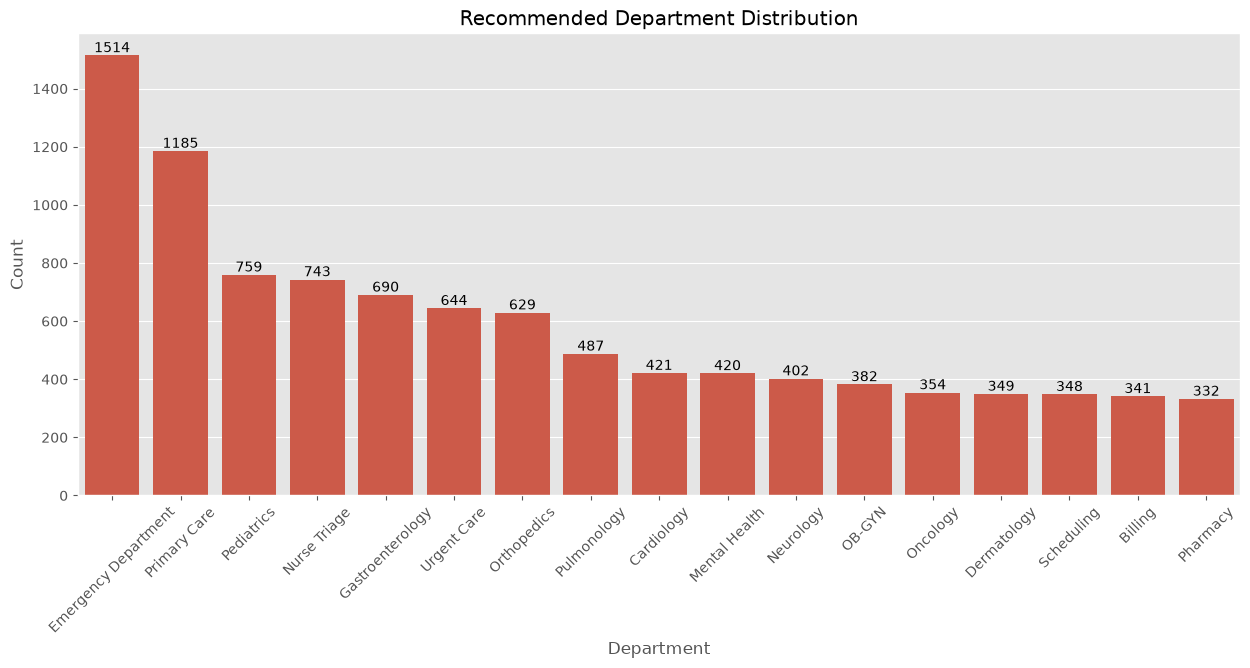

In [45]:
plt.figure(figsize=(15, 6))
ax = sns.countplot(data=df, x="Recommended_Department", order=df["Recommended_Department"].value_counts().index)

# Add count labels on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title("Recommended Department Distribution")
plt.xlabel("Department")
plt.ylabel("Count")

plt.show()

# Bivariate Analysis

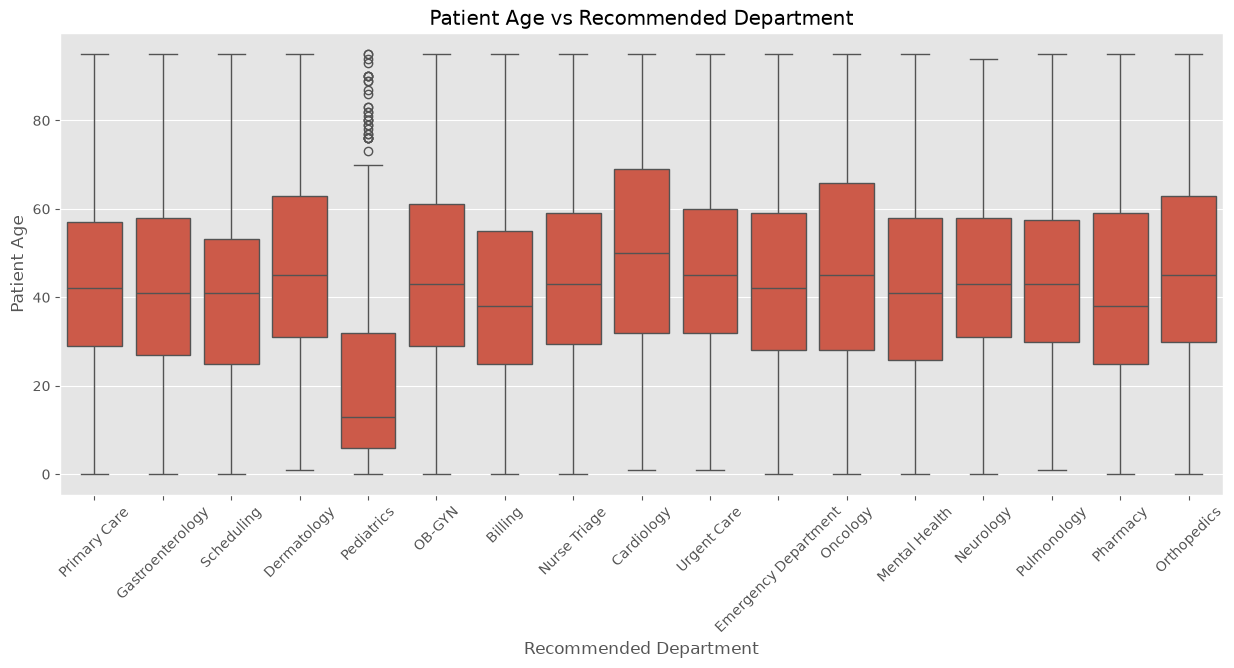

In [48]:
# Patient Age vs Recommended Department
plt.figure(figsize=(15,6))
sns.boxplot(data=df, x="Recommended_Department", y="Patient_Age")

plt.xticks(rotation=45)
plt.title("Patient Age vs Recommended Department")
plt.xlabel("Recommended Department")
plt.ylabel("Patient Age")

plt.show()

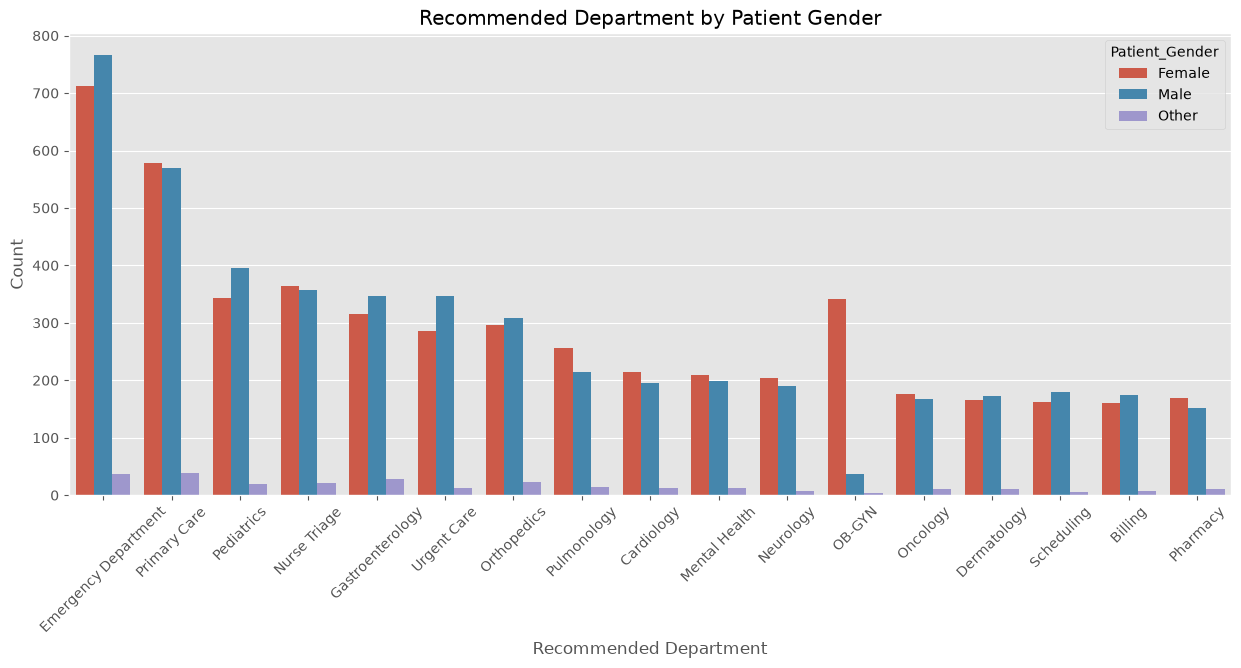

In [60]:
# Patient Gender vs Recommended Department
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="Recommended_Department", hue="Patient_Gender", order=df["Recommended_Department"].value_counts().index)   

plt.xticks(rotation=45)

plt.title("Recommended Department by Patient Gender")
plt.xlabel("Recommended Department")
plt.ylabel("Count")

plt.show()

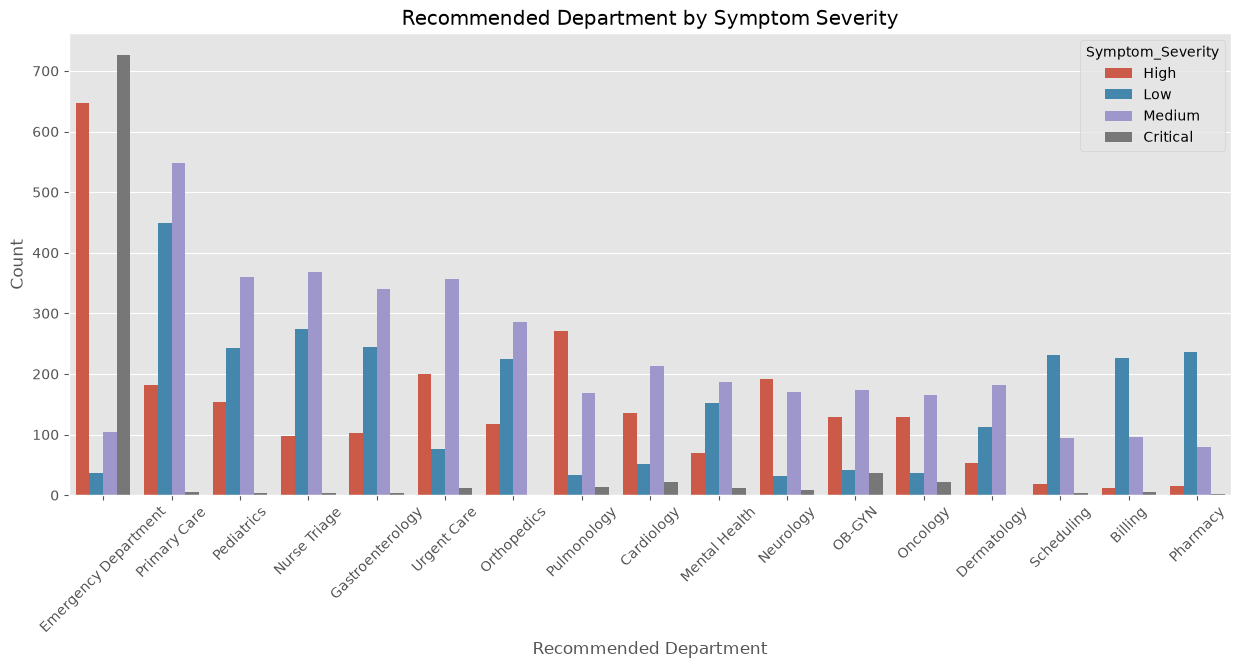

In [61]:
# Symptom Severity vs Recommended Department
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="Recommended_Department", hue="Symptom_Severity", order=df["Recommended_Department"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Recommended Department by Symptom Severity")
plt.xlabel("Recommended Department")
plt.ylabel("Count")

plt.show()

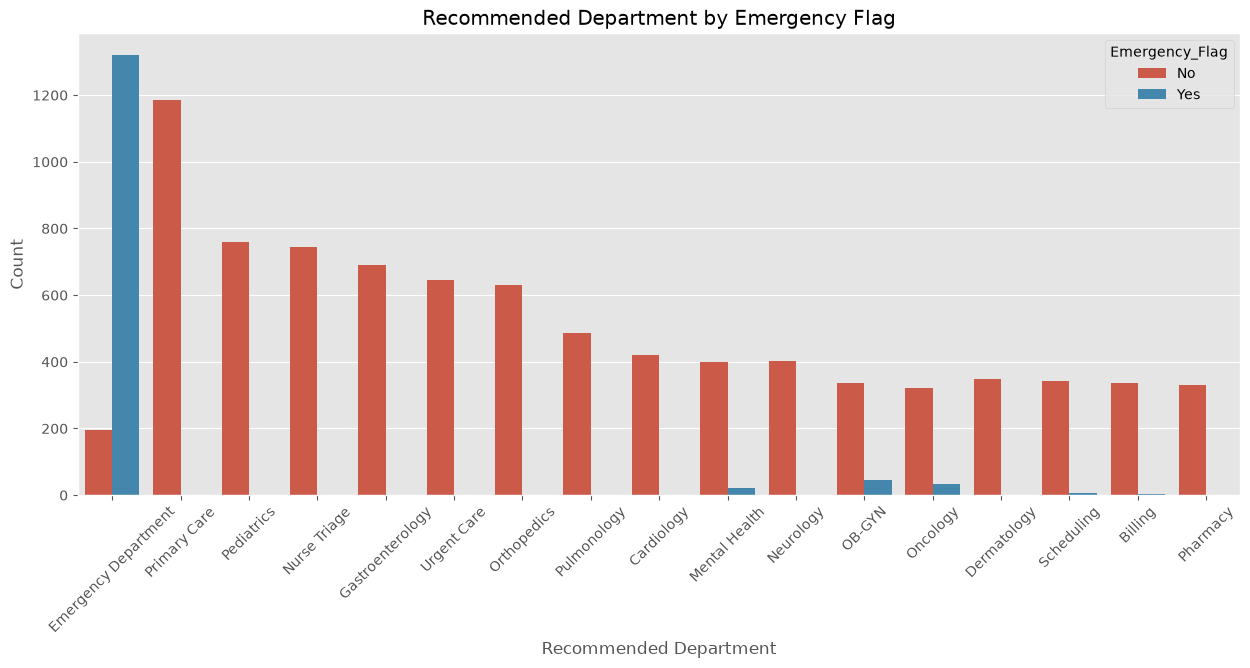

In [62]:
# Emergency Flag vs Recommended Department
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="Recommended_Department", hue="Emergency_Flag", order=df["Recommended_Department"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Recommended Department by Emergency Flag")
plt.xlabel("Recommended Department")
plt.ylabel("Count")

plt.show()

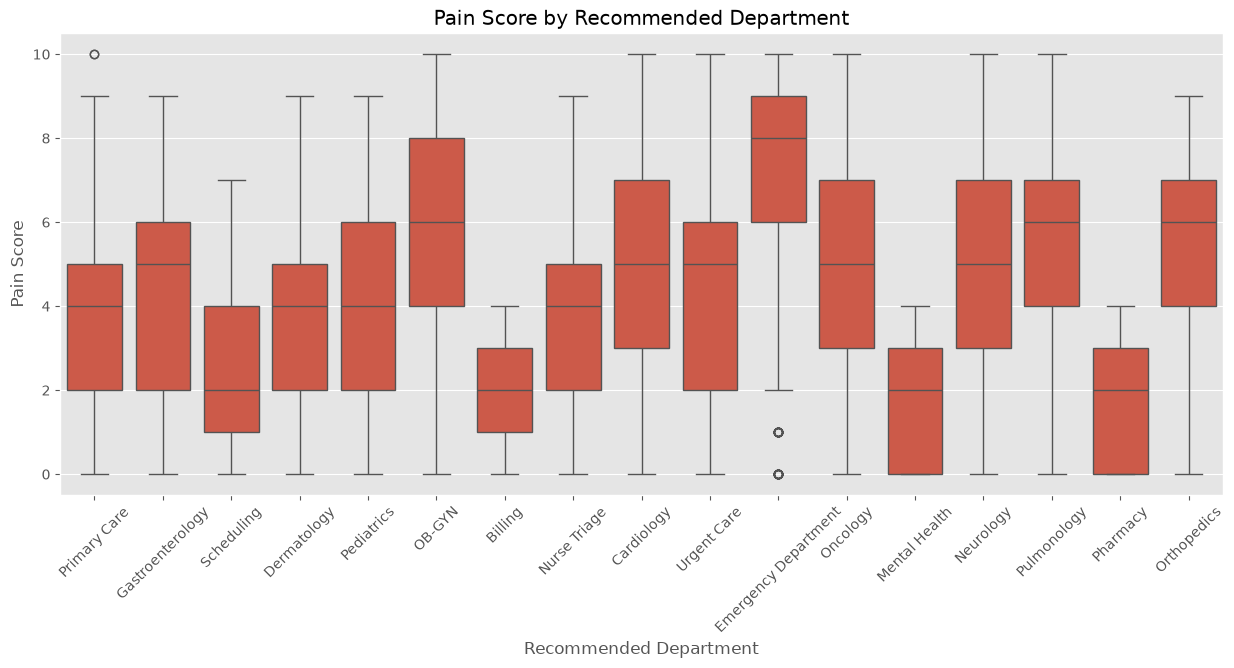

In [63]:
# Pain Score vs Recommended Department
plt.figure(figsize=(15,6))
sns.boxplot(data=df, x="Recommended_Department", y="Pain_Score")

plt.xticks(rotation=45)

plt.title("Pain Score by Recommended Department")
plt.xlabel("Recommended Department")
plt.ylabel("Pain Score")

plt.show()

# NLP Analysis

In [64]:
df["Chief_Complaint"].head()

0                Needs to see a doctor and agent every
1              Caller reports abdominal pain, vomiting
2    Caller reports needs specialist slot, book app...
3      Patient is dealing with skin lesion, acne flare
4           Parent says child has fatigue, weight loss
Name: Chief_Complaint, dtype: object

In [65]:
df["Chief_Complaint"].isnull().sum()

np.int64(0)

In [66]:
(df["Chief_Complaint"].str.strip() == "").sum()

np.int64(0)

In [68]:
df["Character_Count"] = df["Chief_Complaint"].str.len()
df["Character_Count"].describe()

count    10000.0000
mean        43.5068
std         11.4152
min         19.0000
25%         34.0000
50%         43.0000
75%         52.0000
max         89.0000
Name: Character_Count, dtype: float64

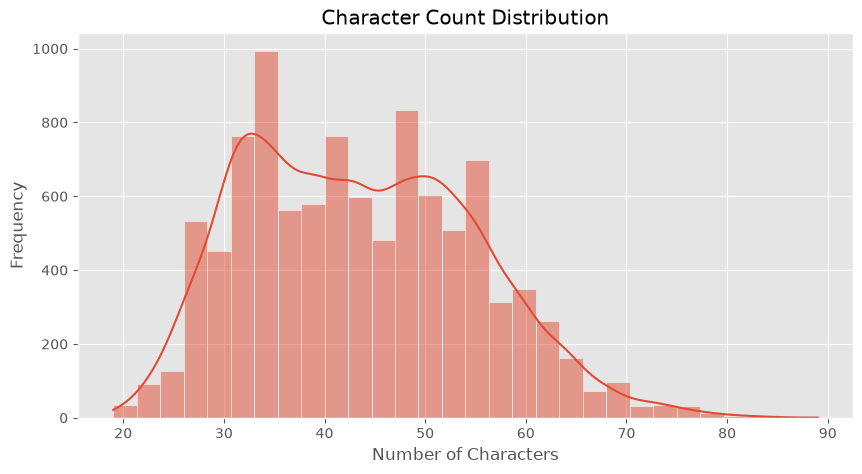

In [69]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Character_Count", bins=30, kde=True)

plt.title("Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [71]:
# Word Count Distribution
df["Word_Count"] = df["Chief_Complaint"].str.split().apply(len)
df["Word_Count"].describe() 

count    10000.000000
mean         6.409400
std          1.711223
min          3.000000
25%          5.000000
50%          6.000000
75%          8.000000
max         14.000000
Name: Word_Count, dtype: float64

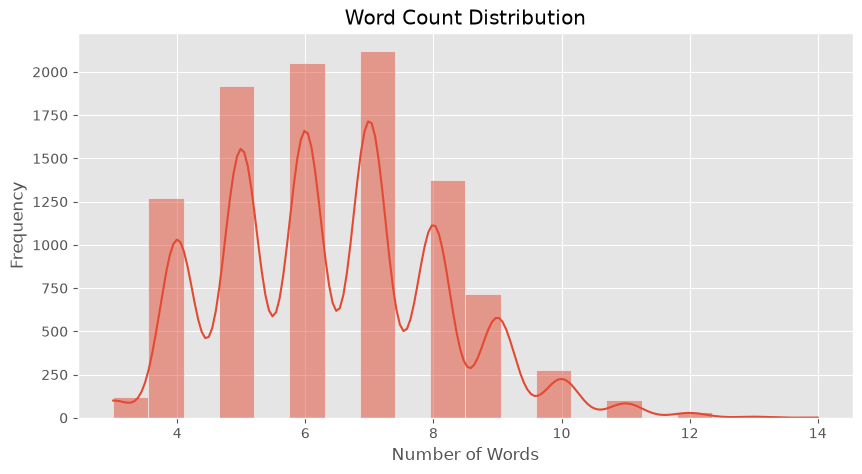

In [72]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Word_Count", bins=20, kde=True)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [73]:
# longest complaint
df.loc[df["Word_Count"].idxmax(), "Chief_Complaint"]

'Needs to see a doctor and since everyone attorney especially official on item at'

In [74]:
# shortest complaint
df.loc[df["Word_Count"].idxmin(), "Chief_Complaint"]

'Caller reports palpitations'

In [76]:
from collections import Counter
text = " ".join(df["Chief_Complaint"])
words = text.lower().split()
common_words = Counter(words).most_common(20)
common_words

[('about', 3695),
 ('concern', 2796),
 ('with', 2432),
 ('and', 2020),
 ('patient', 1849),
 ('is', 1849),
 ('dealing', 1849),
 ('calling', 1772),
 ('caller', 1765),
 ('reports', 1765),
 ('self', 1263),
 ('pain', 981),
 ('symptoms', 675),
 ('worsening', 567),
 ('discomfort', 548),
 ('medication', 526),
 ('pain,', 525),
 ('needs', 501),
 ('notable', 501),
 ('mild', 497)]

In [77]:
common_words_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])
common_words_df

,Word,Frequency
0,about,3695
1,concern,2796
2,with,2432
3,and,2020
4,patient,1849
5,is,1849
6,dealing,1849
7,calling,1772
8,caller,1765
9,reports,1765


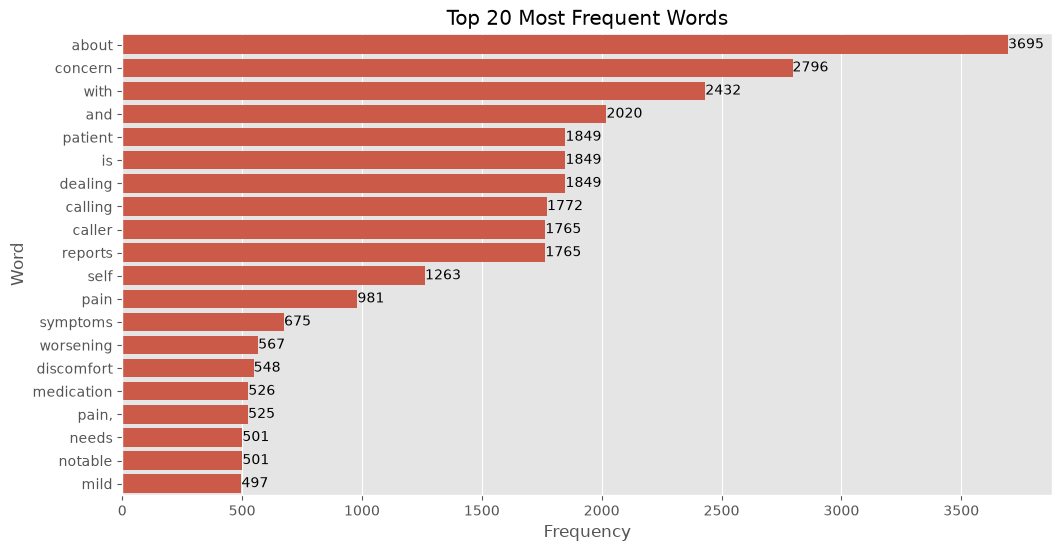

In [79]:
plt.figure(figsize=(12,6))
ax = sns.barplot(data=common_words_df, x="Frequency", y="Word")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

# Correlation Analysis

In [80]:
numerical_columns = df.select_dtypes(include=["int64", "float64"])
correlation = numerical_columns.corr()
correlation

,Patient_Age,Duration_of_Symptoms_Days,Pain_Score,Call_Duration_Minutes,Wait_Time_Minutes,Character_Count,Word_Count
Patient_Age,1.000000,0.019486,0.027211,-0.000232,-0.021075,0.007006,-0.002998
Duration_of_Symptoms_Days,0.019486,1.000000,-0.298938,0.073375,0.227932,-0.033129,0.018865
Pain_Score,0.027211,-0.298938,1.000000,-0.115739,-0.365732,0.025267,0.001122
Call_Duration_Minutes,-0.000232,0.073375,-0.115739,1.000000,0.065735,-0.007757,0.011893
Wait_Time_Minutes,-0.021075,0.227932,-0.365732,0.065735,1.000000,-0.041295,-0.011388
Character_Count,0.007006,-0.033129,0.025267,-0.007757,-0.041295,1.000000,0.891947
Word_Count,-0.002998,0.018865,0.001122,0.011893,-0.011388,0.891947,1.000000


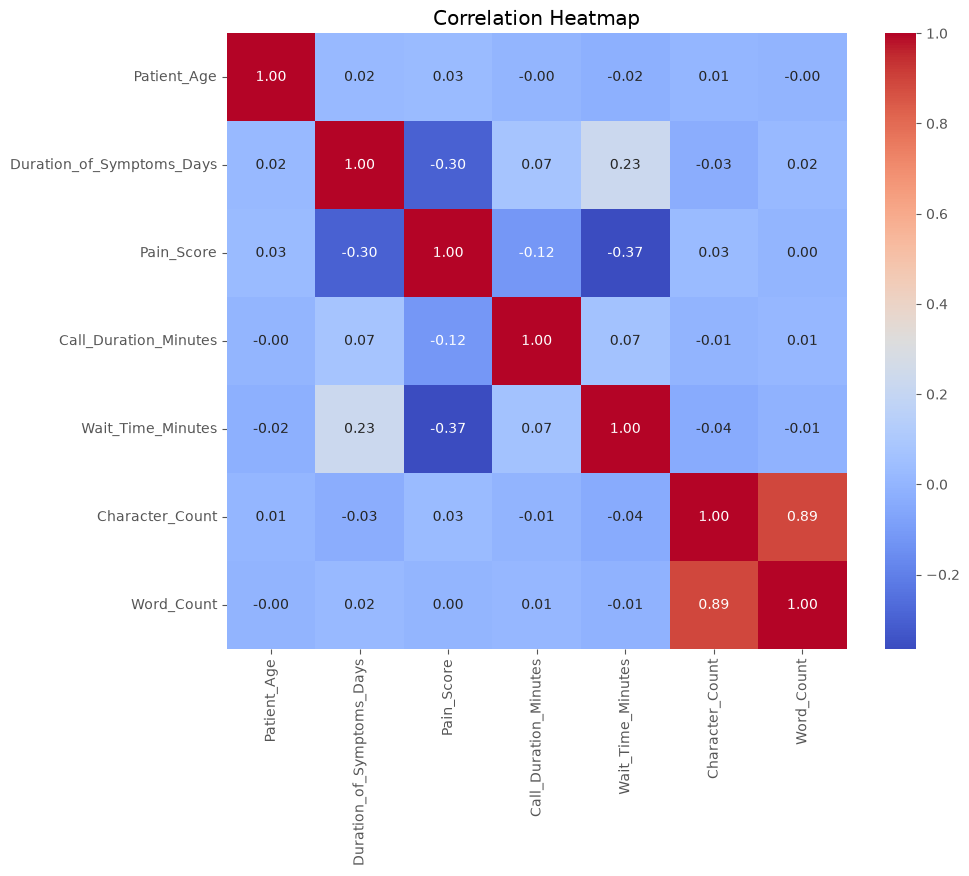

In [81]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# Conclusion

The Exploratory Data Analysis was completed successfully.

Key findings include:

- The dataset is clean and well-structured.
- The target variable is suitable for a multi-class classification problem.
- The Chief Complaint feature contains meaningful text for NLP.
- Important healthcare features are available to improve prediction accuracy.
- The dataset is ready for feature engineering and Machine Learning model development.

The next phase of the project will focus on:

- NLP Preprocessing
- Feature Engineering
- TF-IDF Vectorization
- Train-Test Split
- Preparing data for Machine Learning